In [1]:
# Aim: confirm the mounted notebook-output path and directory structure before building the dataloader

import os

PATCH_INPUT_DIR = "/kaggle/input/notebooks/satwikshreshth01/flood-mapping"

for root, dirs, filenames in os.walk(PATCH_INPUT_DIR):
    print(root, "->", len(filenames), "files")

/kaggle/input/notebooks/satwikshreshth01/flood-mapping -> 7 files
/kaggle/input/notebooks/satwikshreshth01/flood-mapping/__results___files -> 5 files
/kaggle/input/notebooks/satwikshreshth01/flood-mapping/patches -> 7309 files
/kaggle/input/notebooks/satwikshreshth01/flood-mapping/patches/labels_filtered -> 3652 files
/kaggle/input/notebooks/satwikshreshth01/flood-mapping/patches/labels_opened -> 3652 files


In [3]:
# Aim: check contents and file count inside the patches directory to confirm all SAR and label patches survived the attach

patches_dir = os.path.join(PATCH_INPUT_DIR, "patches")

for root, dirs, filenames in os.walk(patches_dir):
    print(root, "->", len(filenames), "files")

/kaggle/input/notebooks/satwikshreshth01/flood-mapping/patches -> 7309 files
/kaggle/input/notebooks/satwikshreshth01/flood-mapping/patches/labels_filtered -> 3652 files
/kaggle/input/notebooks/satwikshreshth01/flood-mapping/patches/labels_opened -> 3652 files


In [4]:
# Aim: load the manifest from the attached notebook output and verify patch/label paths need remapping to the new input location

import pandas as pd

manifest_path = os.path.join(patches_dir, "manifest.csv")
manifest_df = pd.read_csv(manifest_path)

print(manifest_df.shape)
print(manifest_df[["sar_path", "label_path", "label_opened_path"]].head(2))

(3652, 14)
                                sar_path  \
0  /kaggle/working/patches/sar_00000.npy   
1  /kaggle/working/patches/sar_00001.npy   

                                label_path  \
0  /kaggle/working/patches/label_00000.npy   
1  /kaggle/working/patches/label_00001.npy   

                                   label_opened_path  
0  /kaggle/working/patches/labels_opened/label_op...  
1  /kaggle/working/patches/labels_opened/label_op...  


In [5]:
# Aim: remap manifest paths from the original working directory to the attached notebook-output input location

def remap_path(old_path, new_base):
    relative = old_path.split("patches/", 1)[1]
    return os.path.join(new_base, relative)

manifest_df["sar_path"] = manifest_df["sar_path"].apply(lambda p: remap_path(p, patches_dir))
manifest_df["label_path"] = manifest_df["label_path"].apply(lambda p: remap_path(p, patches_dir))
manifest_df["label_filtered_path"] = manifest_df["label_filtered_path"].apply(lambda p: remap_path(p, patches_dir))
manifest_df["label_opened_path"] = manifest_df["label_opened_path"].apply(lambda p: remap_path(p, patches_dir))
manifest_df["label_final_path"] = manifest_df["label_opened_path"]

print(manifest_df[["sar_path", "label_opened_path"]].head(2))
print("sar_path exists check:", os.path.exists(manifest_df["sar_path"].iloc[0]))
print("label_opened_path exists check:", os.path.exists(manifest_df["label_opened_path"].iloc[0]))

                                            sar_path  \
0  /kaggle/input/notebooks/satwikshreshth01/flood...   
1  /kaggle/input/notebooks/satwikshreshth01/flood...   

                                   label_opened_path  
0  /kaggle/input/notebooks/satwikshreshth01/flood...  
1  /kaggle/input/notebooks/satwikshreshth01/flood...  
sar_path exists check: True
label_opened_path exists check: True


In [6]:
# Aim: confirm GPU T4x2 is active and accessible before building the model and dataloader

import torch

print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"Device {i}: {torch.cuda.get_device_name(i)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
Device count: 2
Device 0: Tesla T4
Device 1: Tesla T4
Using device: cuda


In [7]:
# Aim: define a PyTorch Dataset class that loads SAR patches and opened labels from the remapped manifest paths

import numpy as np
from torch.utils.data import Dataset, DataLoader

class FloodPatchDataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest_df = manifest_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        sar = np.load(row["sar_path"]).astype(np.float32)
        label = np.load(row["label_final_path"]).astype(np.float32)

        sar_tensor = torch.from_numpy(sar)
        label_tensor = torch.from_numpy(label).unsqueeze(0)

        if self.transform is not None:
            sar_tensor, label_tensor = self.transform(sar_tensor, label_tensor)

        return sar_tensor, label_tensor

full_dataset = FloodPatchDataset(manifest_df)
sample_sar, sample_label = full_dataset[0]
print("SAR patch shape:", sample_sar.shape, sample_sar.dtype)
print("Label patch shape:", sample_label.shape, sample_label.dtype)

SAR patch shape: torch.Size([6, 256, 256]) torch.float32
Label patch shape: torch.Size([1, 256, 256]) torch.float32


In [9]:
# Aim: introduce a held-out test split, since only train and validation were created so far, using a two-stage stratified split

train_val_df, test_df = train_test_split(
    manifest_df,
    test_size=0.15,
    stratify=manifest_df["density_bin"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    stratify=train_val_df["density_bin"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train patches: {len(train_df)}")
print(f"Validation patches: {len(val_df)}")
print(f"Test patches: {len(test_df)}")
print()
for name, df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"{name} flood_fraction_final mean: {df['flood_fraction_final'].mean():.4f}, std: {df['flood_fraction_final'].std():.4f}")

Train patches: 2638
Validation patches: 466
Test patches: 548

Train flood_fraction_final mean: 0.0921, std: 0.0497
Validation flood_fraction_final mean: 0.0906, std: 0.0484
Test flood_fraction_final mean: 0.0921, std: 0.0488


In [11]:
# Aim: rebuild the dataset class to force writable, owned array copies before tensor conversion, fixing the DataLoader collate error

class FloodPatchDataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest_df = manifest_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        sar = np.array(np.load(row["sar_path"]), dtype=np.float32, copy=True)
        label = np.array(np.load(row["label_final_path"]), dtype=np.float32, copy=True)

        sar_tensor = torch.from_numpy(sar).clone()
        label_tensor = torch.from_numpy(label).unsqueeze(0).clone()

        if self.transform is not None:
            sar_tensor, label_tensor = self.transform(sar_tensor, label_tensor)

        return sar_tensor, label_tensor

train_dataset = FloodPatchDataset(train_df)
val_dataset = FloodPatchDataset(val_df)
test_dataset = FloodPatchDataset(test_df)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

sar_batch, label_batch = next(iter(train_loader))
print("SAR batch shape:", sar_batch.shape)
print("Label batch shape:", label_batch.shape)

SAR batch shape: torch.Size([16, 6, 256, 256])
Label batch shape: torch.Size([16, 1, 256, 256])


In [15]:
# Aim: finalize DataLoaders with num_workers=0, since multiprocessing triggers a storage-resize error tied to the read-only mounted input

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

sar_batch, label_batch = next(iter(train_loader))
print("SAR batch shape:", sar_batch.shape)
print("Label batch shape:", label_batch.shape)
print("Final loader configuration confirmed: num_workers=0, pin_memory=False")

SAR batch shape: torch.Size([16, 6, 256, 256])
Label batch shape: torch.Size([16, 1, 256, 256])
Final loader configuration confirmed: num_workers=0, pin_memory=False


In [16]:
# Aim: define a U-Net architecture with a 6-channel input to match the SAR stack's band count

import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx // 2]
            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)

model = UNet(in_channels=6, out_channels=1).to(device)
model = nn.DataParallel(model)

test_input = torch.randn(2, 6, 256, 256).to(device)
test_output = model(test_input)
print("Test output shape:", test_output.shape)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

Test output shape: torch.Size([2, 1, 256, 256])
Total parameters: 31045249


In [17]:
# Aim: define BCE plus Dice loss combined, matching the loss strategy validated in the earlier SAR flood U-Net project

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        return 1 - dice

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        bce_loss = self.bce(pred, target)
        dice_loss = self.dice(pred, target)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss

criterion = BCEDiceLoss(bce_weight=0.5)

test_pred = torch.randn(2, 1, 256, 256).to(device)
test_target = torch.randint(0, 2, (2, 1, 256, 256)).float().to(device)
test_loss = criterion(test_pred, test_target)
print("Test loss value:", test_loss.item())

Test loss value: 0.6543572545051575


In [18]:
# Aim: set up optimizer, learning rate scheduler, and the core training loop with metrics logged to results.json

import json
import time
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

def dice_coefficient(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    return (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)

def iou_score(pred, target, smooth=1e-6):
    pred = (torch.sigmoid(pred) > 0.5).float()
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)
    intersection = (pred_flat * target_flat).sum()
    union = pred_flat.sum() + target_flat.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def run_epoch(loader, model, criterion, optimizer=None, train=True):
    model.train() if train else model.eval()
    total_loss, total_dice, total_iou = 0.0, 0.0, 0.0

    with torch.set_grad_enabled(train):
        for sar, label in loader:
            sar, label = sar.to(device), label.to(device)

            if train:
                optimizer.zero_grad()

            output = model(sar)
            loss = criterion(output, label)

            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * sar.size(0)
            total_dice += dice_coefficient(output, label).item() * sar.size(0)
            total_iou += iou_score(output, label).item() * sar.size(0)

    n = len(loader.dataset)
    return total_loss / n, total_dice / n, total_iou / n

print("Training loop defined. Ready to run a single epoch as a smoke test before the full run.")

Training loop defined. Ready to run a single epoch as a smoke test before the full run.


In [20]:
# Aim: pad any undersized boundary patches to 256x256 at load time, fixing the batch stacking error

PATCH_SIZE = 256

class FloodPatchDataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest_df = manifest_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.manifest_df)

    def _pad_to_size(self, array, target_size, pad_value=0.0):
        if array.ndim == 3:
            _, h, w = array.shape
            pad_h = target_size - h
            pad_w = target_size - w
            if pad_h > 0 or pad_w > 0:
                array = np.pad(array, ((0, 0), (0, max(pad_h, 0)), (0, max(pad_w, 0))), mode="constant", constant_values=pad_value)
        else:
            h, w = array.shape
            pad_h = target_size - h
            pad_w = target_size - w
            if pad_h > 0 or pad_w > 0:
                array = np.pad(array, ((0, max(pad_h, 0)), (0, max(pad_w, 0))), mode="constant", constant_values=pad_value)
        return array

    def __getitem__(self, idx):
        row = self.manifest_df.iloc[idx]
        sar = np.array(np.load(row["sar_path"]), dtype=np.float32, copy=True)
        label = np.array(np.load(row["label_final_path"]), dtype=np.float32, copy=True)

        sar = self._pad_to_size(sar, PATCH_SIZE, pad_value=0.0)
        label = self._pad_to_size(label, PATCH_SIZE, pad_value=0.0)

        sar_tensor = torch.from_numpy(sar).clone()
        label_tensor = torch.from_numpy(label).unsqueeze(0).clone()

        if self.transform is not None:
            sar_tensor, label_tensor = self.transform(sar_tensor, label_tensor)

        return sar_tensor, label_tensor

train_dataset = FloodPatchDataset(train_df)
val_dataset = FloodPatchDataset(val_df)
test_dataset = FloodPatchDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

shapes = set()
for sar, label in train_loader:
    shapes.add((sar.shape[2], sar.shape[3]))
print("Unique spatial shapes seen across all training batches:", shapes)

Unique spatial shapes seen across all training batches: {(256, 256)}


In [23]:
# Aim: define the full training loop with checkpointing, early stopping, and metrics logged to results.json

NUM_EPOCHS = 200
PATIENCE = 15
CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

best_val_dice = 0.0
epochs_without_improvement = 0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_dice, train_iou = run_epoch(train_loader, model, criterion, optimizer, train=True)
    val_loss, val_dice, val_iou = run_epoch(val_loader, model, criterion, optimizer=None, train=False)

    scheduler.step(val_loss)
    epoch_time = time.time() - epoch_start

    history.append({
        "epoch": epoch,
        "train_loss": train_loss, "train_dice": train_dice, "train_iou": train_iou,
        "val_loss": val_loss, "val_dice": val_dice, "val_iou": val_iou,
        "epoch_time_sec": epoch_time,
        "lr": optimizer.param_groups[0]["lr"],
    })

    with open("/kaggle/working/results.json", "w") as f:
        json.dump(history, f, indent=2)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} dice={train_dice:.4f} | "
          f"val_loss={val_loss:.4f} dice={val_dice:.4f} iou={val_iou:.4f} | {epoch_time:.1f}s")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        epochs_without_improvement = 0
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pt"))
        print(f"  -> new best model saved, val_dice={val_dice:.4f}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered after {epoch} epochs, no improvement for {PATIENCE} epochs")
        break

print("Training complete.")
print(f"Best validation Dice: {best_val_dice:.4f}")

Epoch 01 | train_loss=0.4844 dice=0.7708 | val_loss=0.4602 dice=0.7920 iou=0.6560 | 117.9s
  -> new best model saved, val_dice=0.7920
Epoch 02 | train_loss=0.4170 dice=0.8108 | val_loss=0.3755 dice=0.8463 iou=0.7336 | 111.2s
  -> new best model saved, val_dice=0.8463
Epoch 03 | train_loss=0.3594 dice=0.8280 | val_loss=0.3256 dice=0.8646 iou=0.7617 | 130.6s
  -> new best model saved, val_dice=0.8646
Epoch 04 | train_loss=0.3102 dice=0.8408 | val_loss=0.2789 dice=0.8717 iou=0.7726 | 118.2s
  -> new best model saved, val_dice=0.8717
Epoch 05 | train_loss=0.2683 dice=0.8506 | val_loss=0.2345 dice=0.8789 iou=0.7841 | 106.0s
  -> new best model saved, val_dice=0.8789
Epoch 06 | train_loss=0.2342 dice=0.8562 | val_loss=0.2088 dice=0.8753 iou=0.7784 | 106.1s
Epoch 07 | train_loss=0.2044 dice=0.8645 | val_loss=0.1755 dice=0.8914 iou=0.8041 | 106.4s
  -> new best model saved, val_dice=0.8914
Epoch 08 | train_loss=0.1805 dice=0.8709 | val_loss=0.1559 dice=0.8967 iou=0.8128 | 106.4s
  -> new best 

In [24]:
# Aim: load the best checkpoint and evaluate it on the held-out test set for an unbiased final performance measure

model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best_model.pt")))

test_loss, test_dice, test_iou = run_epoch(test_loader, model, criterion, optimizer=None, train=False)

print(f"Test loss: {test_loss:.4f}")
print(f"Test Dice: {test_dice:.4f}")
print(f"Test IoU: {test_iou:.4f}")

final_results = {
    "best_val_dice": best_val_dice,
    "test_loss": test_loss,
    "test_dice": test_dice,
    "test_iou": test_iou,
    "total_epochs_trained": len(history),
}

with open("/kaggle/working/final_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("Final results saved to /kaggle/working/final_results.json")

Test loss: 0.0387
Test Dice: 0.9593
Test IoU: 0.9218
Final results saved to /kaggle/working/final_results.json


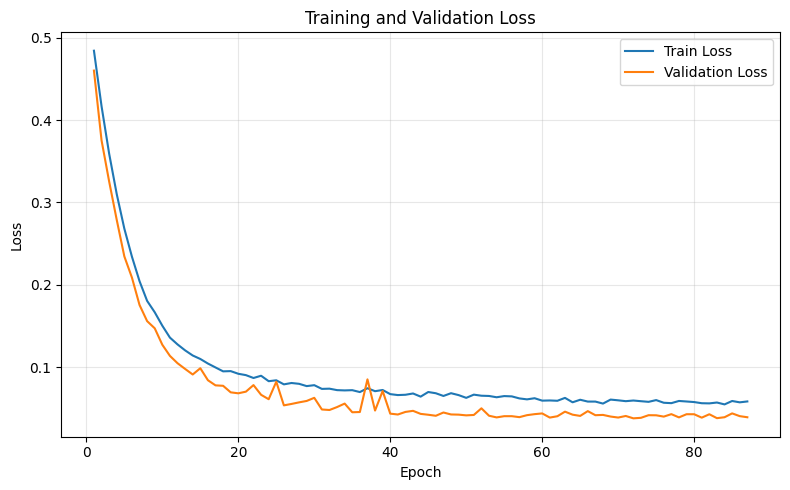

Saved: fig1a_loss_curve.png


In [26]:
# Aim: plot training vs validation loss curve as a standalone figure

import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/fig1a_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig1a_loss_curve.png")

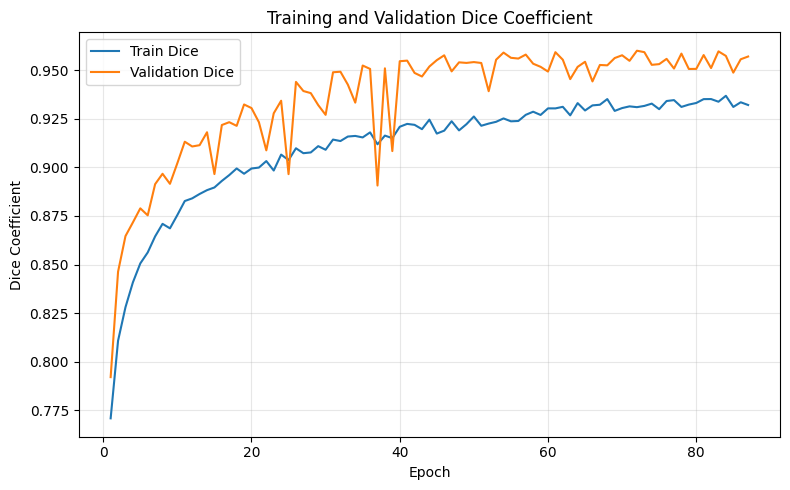

Saved: fig1b_dice_curve.png


In [27]:
# Aim: plot training vs validation Dice coefficient curve as a standalone figure

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["train_dice"], label="Train Dice")
ax.plot(history_df["epoch"], history_df["val_dice"], label="Validation Dice")
ax.set_xlabel("Epoch")
ax.set_ylabel("Dice Coefficient")
ax.set_title("Training and Validation Dice Coefficient")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/fig1b_dice_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig1b_dice_curve.png")

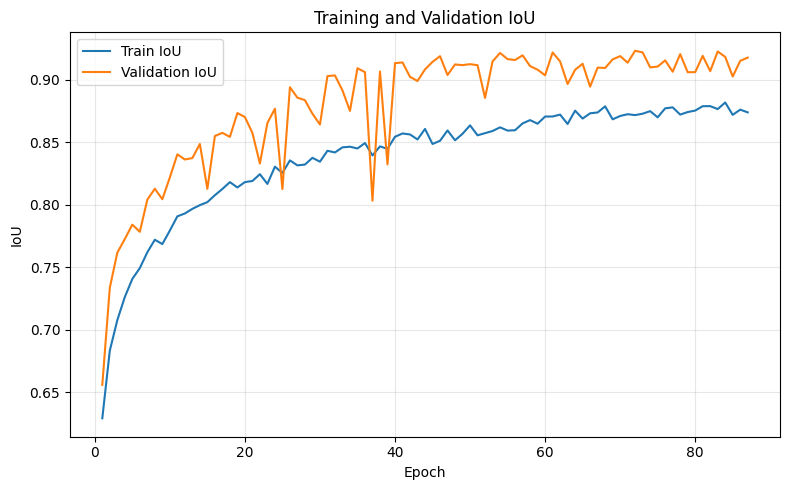

Saved: fig1c_iou_curve.png


In [28]:
# Aim: plot training vs validation IoU curve as a standalone figure

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["train_iou"], label="Train IoU")
ax.plot(history_df["epoch"], history_df["val_iou"], label="Validation IoU")
ax.set_xlabel("Epoch")
ax.set_ylabel("IoU")
ax.set_title("Training and Validation IoU")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/fig1c_iou_curve.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig1c_iou_curve.png")

In [29]:
# Aim: compute pixel-level confusion matrix and precision/recall/F1 on the test set

from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for sar, label in test_loader:
        sar = sar.to(device)
        output = model(sar)
        pred = (torch.sigmoid(output) > 0.5).cpu().numpy().astype(np.uint8)
        target = label.numpy().astype(np.uint8)
        all_preds.append(pred.flatten())
        all_targets.append(target.flatten())

all_preds = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

cm = confusion_matrix(all_targets, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average="binary")
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("Confusion matrix (rows=true, cols=predicted):")
print(cm)
print()
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion matrix (rows=true, cols=predicted):
[[32502727   134041]
 [  130979  3145981]]

Precision: 0.9591
Recall: 0.9600
F1 Score: 0.9596
Specificity: 0.9959


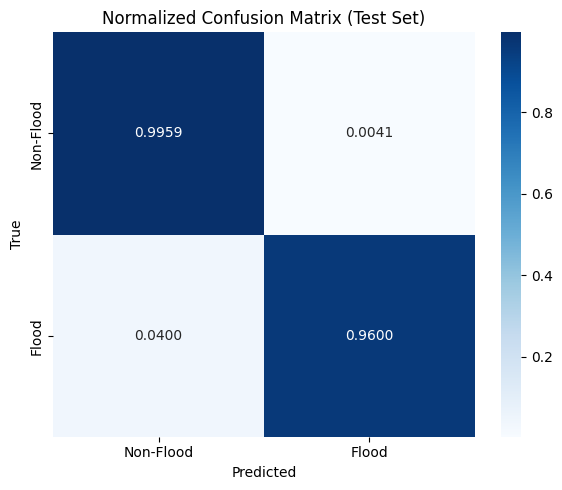

Saved: fig2_confusion_matrix.png


In [30]:
# Aim: plot the normalized confusion matrix as a standalone heatmap figure

import seaborn as sns

cm_normalized = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt=".4f", cmap="Blues",
            xticklabels=["Non-Flood", "Flood"], yticklabels=["Non-Flood", "Flood"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Normalized Confusion Matrix (Test Set)")

plt.tight_layout()
plt.savefig("/kaggle/working/fig2_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig2_confusion_matrix.png")

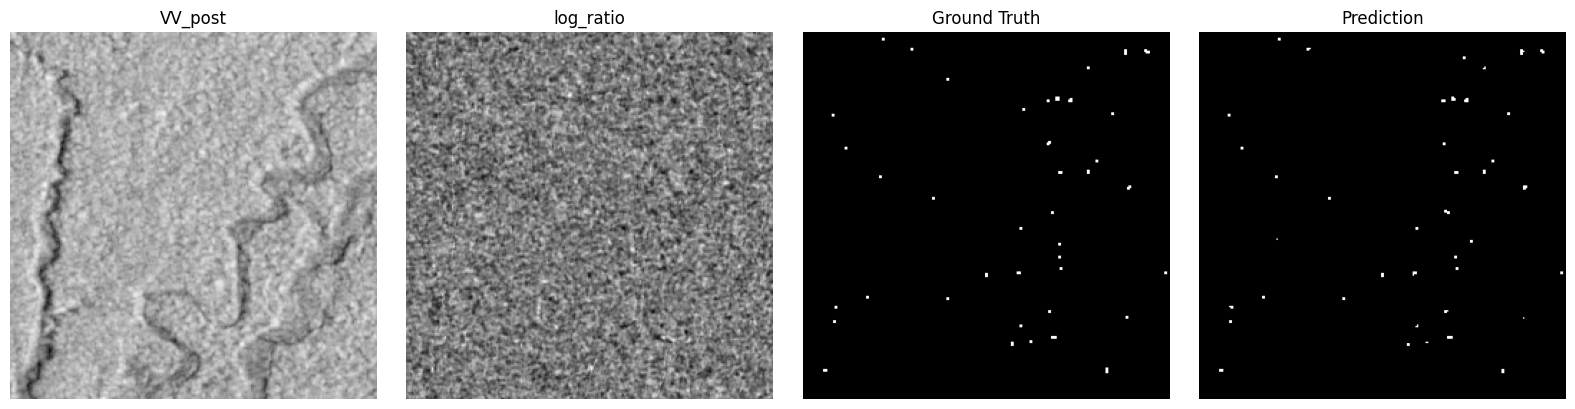

Saved: fig3a_qualitative_low_density.png


In [31]:
# Aim: plot qualitative prediction comparison for the lowest flood-density test patch

test_df_indexed = test_df.reset_index(drop=True)
density_sorted = test_df_indexed.sort_values("flood_fraction_final")

low_idx = density_sorted.index[0]
sar, label = test_dataset[low_idx]

model.eval()
with torch.no_grad():
    sar_batch_single = sar.unsqueeze(0).to(device)
    output = model(sar_batch_single)
    pred = (torch.sigmoid(output) > 0.5).cpu().numpy()[0, 0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sar[0].numpy(), cmap="gray")
axes[0].set_title("VV_post")
axes[0].axis("off")

axes[1].imshow(sar[4].numpy(), cmap="gray")
axes[1].set_title("log_ratio")
axes[1].axis("off")

axes[2].imshow(label[0].numpy(), cmap="gray")
axes[2].set_title("Ground Truth")
axes[2].axis("off")

axes[3].imshow(pred, cmap="gray")
axes[3].set_title("Prediction")
axes[3].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/fig3a_qualitative_low_density.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig3a_qualitative_low_density.png")

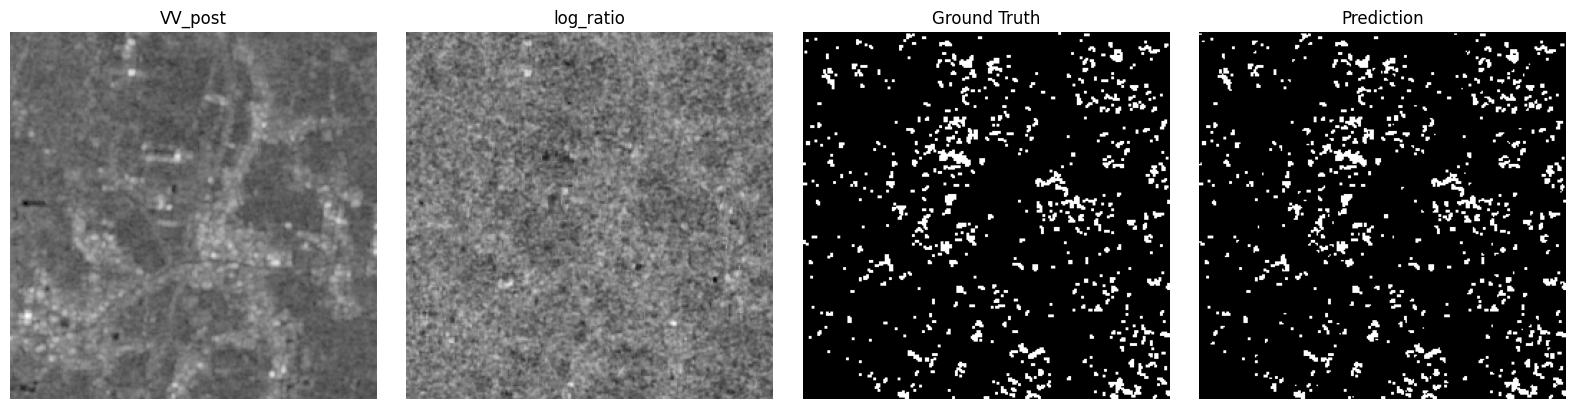

Saved: fig3b_qualitative_medium_density.png


In [32]:
# Aim: plot qualitative prediction comparison for the median flood-density test patch

mid_idx = density_sorted.index[len(density_sorted) // 2]
sar, label = test_dataset[mid_idx]

model.eval()
with torch.no_grad():
    sar_batch_single = sar.unsqueeze(0).to(device)
    output = model(sar_batch_single)
    pred = (torch.sigmoid(output) > 0.5).cpu().numpy()[0, 0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sar[0].numpy(), cmap="gray")
axes[0].set_title("VV_post")
axes[0].axis("off")

axes[1].imshow(sar[4].numpy(), cmap="gray")
axes[1].set_title("log_ratio")
axes[1].axis("off")

axes[2].imshow(label[0].numpy(), cmap="gray")
axes[2].set_title("Ground Truth")
axes[2].axis("off")

axes[3].imshow(pred, cmap="gray")
axes[3].set_title("Prediction")
axes[3].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/fig3b_qualitative_medium_density.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig3b_qualitative_medium_density.png")

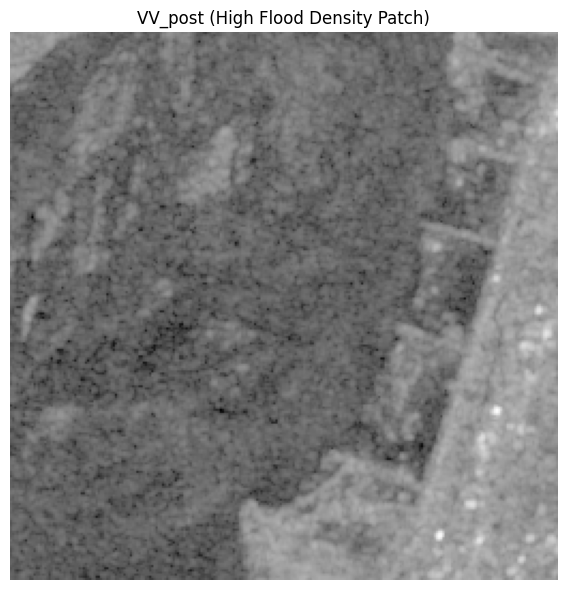

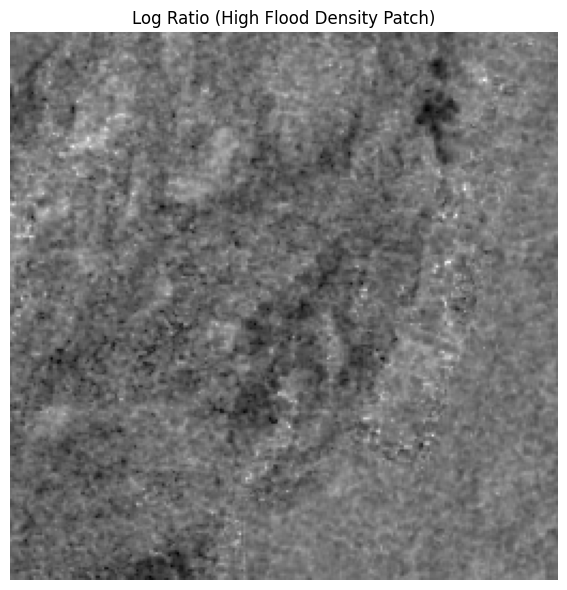

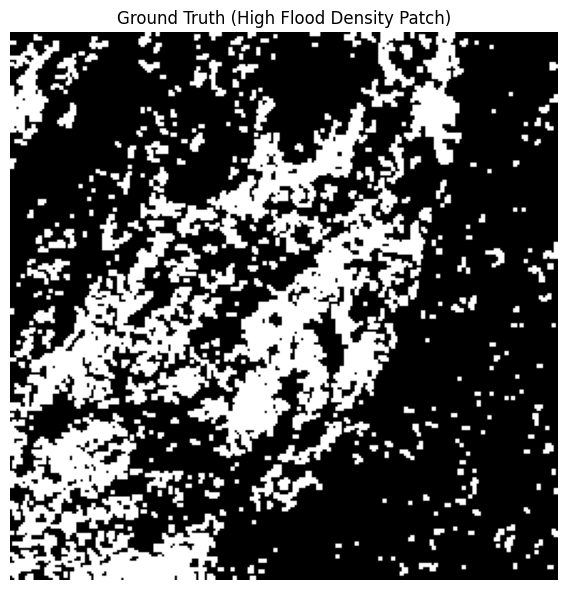

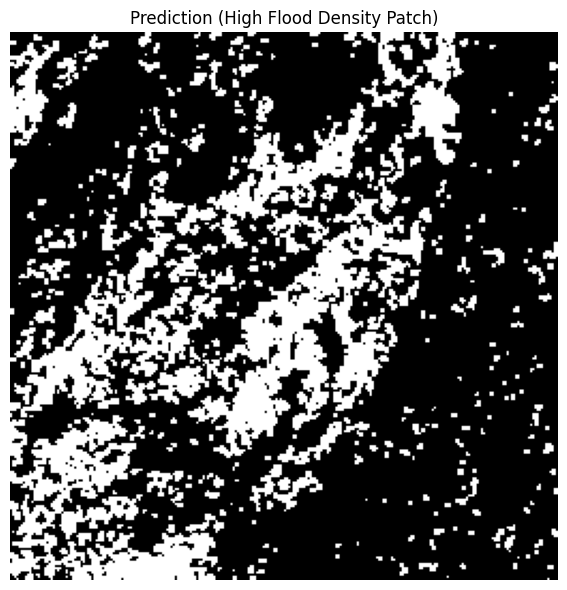

Saved: fig3c_high_density_vv_post.png, fig3d_high_density_log_ratio.png, fig3e_high_density_ground_truth.png, fig3f_high_density_prediction.png


In [33]:
# Aim: plot each panel of the high-density qualitative comparison as its own separate figure, all generated in this one cell

high_idx = density_sorted.index[-1]
sar, label = test_dataset[high_idx]

model.eval()
with torch.no_grad():
    sar_batch_single = sar.unsqueeze(0).to(device)
    output = model(sar_batch_single)
    pred = (torch.sigmoid(output) > 0.5).cpu().numpy()[0, 0]

fig1 = plt.figure(figsize=(6, 6))
plt.imshow(sar[0].numpy(), cmap="gray")
plt.title("VV_post (High Flood Density Patch)")
plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/fig3c_high_density_vv_post.png", dpi=300, bbox_inches="tight")
plt.show()

fig2 = plt.figure(figsize=(6, 6))
plt.imshow(sar[4].numpy(), cmap="gray")
plt.title("Log Ratio (High Flood Density Patch)")
plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/fig3d_high_density_log_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

fig3 = plt.figure(figsize=(6, 6))
plt.imshow(label[0].numpy(), cmap="gray")
plt.title("Ground Truth (High Flood Density Patch)")
plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/fig3e_high_density_ground_truth.png", dpi=300, bbox_inches="tight")
plt.show()

fig4 = plt.figure(figsize=(6, 6))
plt.imshow(pred, cmap="gray")
plt.title("Prediction (High Flood Density Patch)")
plt.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/fig3f_high_density_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig3c_high_density_vv_post.png, fig3d_high_density_log_ratio.png, fig3e_high_density_ground_truth.png, fig3f_high_density_prediction.png")

In [34]:
# Aim: save the final trained model checkpoint and compile the complete results summary for the paper

torch.save(model.state_dict(), "/kaggle/working/checkpoints/final_model.pt")

summary = {
    "model": "U-Net (6-channel input, features=[64,128,256,512])",
    "total_parameters": int(sum(p.numel() for p in model.parameters())),
    "input_bands": ["VV_post", "VH_post", "VV_pre", "VH_pre", "log_ratio", "elevation"],
    "loss_function": "BCE + Dice (0.5 weight each)",
    "optimizer": "Adam, lr=1e-4, ReduceLROnPlateau",
    "total_epochs_trained": len(history),
    "early_stopping_patience": PATIENCE,
    "dataset": {
        "total_patches": len(manifest_df),
        "patch_size": PATCH_SIZE,
        "train_patches": len(train_df),
        "val_patches": len(val_df),
        "test_patches": len(test_df),
        "mean_flood_fraction": float(manifest_df["flood_fraction_final"].mean()),
    },
    "test_metrics": {
        "loss": test_loss,
        "dice": test_dice,
        "iou": test_iou,
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "specificity": float(specificity),
    },
    "confusion_matrix": cm.tolist(),
}

with open("/kaggle/working/paper_results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

metrics_table = pd.DataFrame([{
    "Model": "U-Net (6-channel SAR)",
    "Dice": f"{test_dice:.4f}",
    "IoU": f"{test_iou:.4f}",
    "Precision": f"{precision:.4f}",
    "Recall": f"{recall:.4f}",
    "F1": f"{f1:.4f}",
    "Specificity": f"{specificity:.4f}",
}])
metrics_table.to_csv("/kaggle/working/paper_metrics_table.csv", index=False)

print(metrics_table.to_string(index=False))
print()
print("Saved: final_model.pt, paper_results_summary.json, paper_metrics_table.csv")

                Model   Dice    IoU Precision Recall     F1 Specificity
U-Net (6-channel SAR) 0.9593 0.9218    0.9591 0.9600 0.9596      0.9959

Saved: final_model.pt, paper_results_summary.json, paper_metrics_table.csv


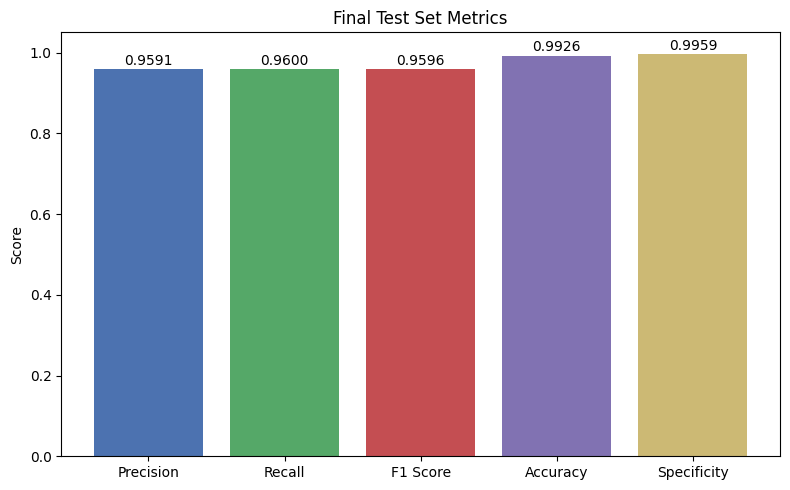

Saved: fig4_final_metrics_bar.png


In [35]:
# Aim: compute accuracy on the test set and plot precision, recall, F1, and accuracy as a final-result bar chart

accuracy = (tp + tn) / (tp + tn + fp + fn)

metrics_names = ["Precision", "Recall", "F1 Score", "Accuracy", "Specificity"]
metrics_values = [precision, recall, f1, accuracy, specificity]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics_names, metrics_values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Final Test Set Metrics")

for bar, value in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.4f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("/kaggle/working/fig4_final_metrics_bar.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig4_final_metrics_bar.png")

In [36]:
# Aim: implement Otsu threshold baseline on the log_ratio band for comparison against the U-Net, evaluated on the same test set

from skimage.filters import threshold_otsu

def otsu_predict(log_ratio_band):
    valid_mask = log_ratio_band != 0
    if valid_mask.sum() == 0:
        return np.zeros_like(log_ratio_band, dtype=np.uint8)
    thresh = threshold_otsu(log_ratio_band[valid_mask])
    pred = (log_ratio_band < thresh).astype(np.uint8)
    return pred

baseline_preds = []
baseline_targets = []

for idx in range(len(test_dataset)):
    sar, label = test_dataset[idx]
    log_ratio_band = sar[4].numpy()
    label_np = label[0].numpy().astype(np.uint8)

    pred = otsu_predict(log_ratio_band)

    baseline_preds.append(pred.flatten())
    baseline_targets.append(label_np.flatten())

baseline_preds = np.concatenate(baseline_preds)
baseline_targets = np.concatenate(baseline_targets)

baseline_cm = confusion_matrix(baseline_targets, baseline_preds)
baseline_precision, baseline_recall, baseline_f1, _ = precision_recall_fscore_support(baseline_targets, baseline_preds, average="binary")

baseline_tn, baseline_fp, baseline_fn, baseline_tp = baseline_cm.ravel()
baseline_accuracy = (baseline_tp + baseline_tn) / (baseline_tp + baseline_tn + baseline_fp + baseline_fn)
baseline_dice = (2 * baseline_tp) / (2 * baseline_tp + baseline_fp + baseline_fn)
baseline_iou = baseline_tp / (baseline_tp + baseline_fp + baseline_fn)

print("Otsu Baseline Confusion Matrix:")
print(baseline_cm)
print()
print(f"Baseline Dice: {baseline_dice:.4f}")
print(f"Baseline IoU: {baseline_iou:.4f}")
print(f"Baseline Precision: {baseline_precision:.4f}")
print(f"Baseline Recall: {baseline_recall:.4f}")
print(f"Baseline F1: {baseline_f1:.4f}")
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Otsu Baseline Confusion Matrix:
[[16623815 16012953]
 [      10  3276950]]

Baseline Dice: 0.2904
Baseline IoU: 0.1699
Baseline Precision: 0.1699
Baseline Recall: 1.0000
Baseline F1: 0.2904
Baseline Accuracy: 0.5541


In [37]:
# Aim: compute a single global Otsu threshold from the training set log_ratio values, then apply it consistently across the test set

train_log_ratio_values = []

for idx in range(len(train_dataset)):
    sar, label = train_dataset[idx]
    log_ratio_band = sar[4].numpy()
    valid_mask = log_ratio_band != 0
    train_log_ratio_values.append(log_ratio_band[valid_mask])

train_log_ratio_values = np.concatenate(train_log_ratio_values)
global_thresh = threshold_otsu(train_log_ratio_values)

print(f"Global Otsu threshold (from training set log_ratio): {global_thresh:.4f}")

def otsu_predict_global(log_ratio_band, thresh):
    return (log_ratio_band < thresh).astype(np.uint8)

baseline_preds_v2 = []
baseline_targets_v2 = []

for idx in range(len(test_dataset)):
    sar, label = test_dataset[idx]
    log_ratio_band = sar[4].numpy()
    label_np = label[0].numpy().astype(np.uint8)

    pred = otsu_predict_global(log_ratio_band, global_thresh)

    baseline_preds_v2.append(pred.flatten())
    baseline_targets_v2.append(label_np.flatten())

baseline_preds_v2 = np.concatenate(baseline_preds_v2)
baseline_targets_v2 = np.concatenate(baseline_targets_v2)

baseline_cm_v2 = confusion_matrix(baseline_targets_v2, baseline_preds_v2)
baseline_precision_v2, baseline_recall_v2, baseline_f1_v2, _ = precision_recall_fscore_support(baseline_targets_v2, baseline_preds_v2, average="binary")

btn, bfp, bfn, btp = baseline_cm_v2.ravel()
baseline_accuracy_v2 = (btp + btn) / (btp + btn + bfp + bfn)
baseline_dice_v2 = (2 * btp) / (2 * btp + bfp + bfn)
baseline_iou_v2 = btp / (btp + bfp + bfn)

print("Global-threshold Otsu Baseline Confusion Matrix:")
print(baseline_cm_v2)
print()
print(f"Baseline Dice: {baseline_dice_v2:.4f}")
print(f"Baseline IoU: {baseline_iou_v2:.4f}")
print(f"Baseline Precision: {baseline_precision_v2:.4f}")
print(f"Baseline Recall: {baseline_recall_v2:.4f}")
print(f"Baseline F1: {baseline_f1_v2:.4f}")
print(f"Baseline Accuracy: {baseline_accuracy_v2:.4f}")

Global Otsu threshold (from training set log_ratio): 0.2416
Global-threshold Otsu Baseline Confusion Matrix:
[[14702289 17934479]
 [       0  3276960]]

Baseline Dice: 0.2676
Baseline IoU: 0.1545
Baseline Precision: 0.1545
Baseline Recall: 1.0000
Baseline F1: 0.2676
Baseline Accuracy: 0.5006


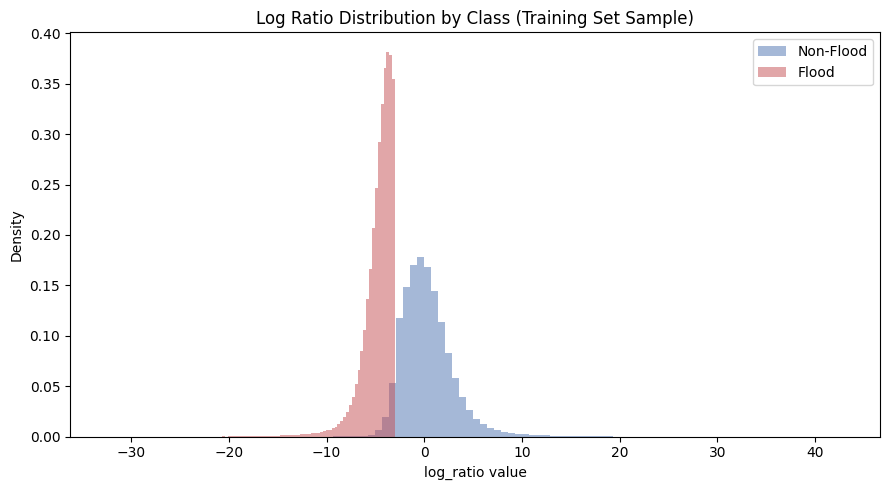

Flood log_ratio: mean=-4.7517, std=1.6138
Non-flood log_ratio: mean=0.3362, std=2.6348


In [38]:
# Aim: plot log_ratio value distributions separately for flood and non-flood pixels to check whether the band is genuinely separable

sample_log_ratio = []
sample_labels = []

for idx in range(0, len(train_dataset), 5):  # subsample every 5th patch to keep this fast
    sar, label = train_dataset[idx]
    log_ratio_band = sar[4].numpy()
    label_np = label[0].numpy().astype(np.uint8)
    valid_mask = log_ratio_band != 0

    sample_log_ratio.append(log_ratio_band[valid_mask])
    sample_labels.append(label_np[valid_mask])

sample_log_ratio = np.concatenate(sample_log_ratio)
sample_labels = np.concatenate(sample_labels)

flood_values = sample_log_ratio[sample_labels == 1]
nonflood_values = sample_log_ratio[sample_labels == 0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(nonflood_values, bins=100, alpha=0.5, label="Non-Flood", density=True, color="#4C72B0")
ax.hist(flood_values, bins=100, alpha=0.5, label="Flood", density=True, color="#C44E52")
ax.set_xlabel("log_ratio value")
ax.set_ylabel("Density")
ax.set_title("Log Ratio Distribution by Class (Training Set Sample)")
ax.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/fig5_log_ratio_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Flood log_ratio: mean={flood_values.mean():.4f}, std={flood_values.std():.4f}")
print(f"Non-flood log_ratio: mean={nonflood_values.mean():.4f}, std={nonflood_values.std():.4f}")

In [39]:
# Aim: find the label-informed optimal threshold on training data via ROC analysis, replacing the unsupervised Otsu approach

from sklearn.metrics import roc_curve

train_log_ratio_values = []
train_labels_flat = []

for idx in range(0, len(train_dataset), 3):
    sar, label = train_dataset[idx]
    log_ratio_band = sar[4].numpy()
    label_np = label[0].numpy().astype(np.uint8)
    valid_mask = log_ratio_band != 0

    train_log_ratio_values.append(log_ratio_band[valid_mask])
    train_labels_flat.append(label_np[valid_mask])

train_log_ratio_values = np.concatenate(train_log_ratio_values)
train_labels_flat = np.concatenate(train_labels_flat)

# flood pixels have lower log_ratio, so invert the score for roc_curve's convention
fpr, tpr, thresholds = roc_curve(train_labels_flat, -train_log_ratio_values)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
optimal_thresh = -thresholds[best_idx]

print(f"Optimal threshold (Youden's J, from training labels): {optimal_thresh:.4f}")
print(f"At this threshold: TPR={tpr[best_idx]:.4f}, FPR={fpr[best_idx]:.4f}")

Optimal threshold (Youden's J, from training labels): -3.0000
At this threshold: TPR=1.0000, FPR=0.0476


In [40]:
# Aim: apply the label-informed optimal threshold to the test set and recompute baseline metrics for fair comparison against the U-Net

def otsu_predict_global(log_ratio_band, thresh):
    return (log_ratio_band < thresh).astype(np.uint8)

baseline_preds_v3 = []
baseline_targets_v3 = []

for idx in range(len(test_dataset)):
    sar, label = test_dataset[idx]
    log_ratio_band = sar[4].numpy()
    label_np = label[0].numpy().astype(np.uint8)

    pred = otsu_predict_global(log_ratio_band, optimal_thresh)

    baseline_preds_v3.append(pred.flatten())
    baseline_targets_v3.append(label_np.flatten())

baseline_preds_v3 = np.concatenate(baseline_preds_v3)
baseline_targets_v3 = np.concatenate(baseline_targets_v3)

baseline_cm_v3 = confusion_matrix(baseline_targets_v3, baseline_preds_v3)
baseline_precision_v3, baseline_recall_v3, baseline_f1_v3, _ = precision_recall_fscore_support(baseline_targets_v3, baseline_preds_v3, average="binary")

btn3, bfp3, bfn3, btp3 = baseline_cm_v3.ravel()
baseline_accuracy_v3 = (btp3 + btn3) / (btp3 + btn3 + bfp3 + bfn3)
baseline_dice_v3 = (2 * btp3) / (2 * btp3 + bfp3 + bfn3)
baseline_iou_v3 = btp3 / (btp3 + bfp3 + bfn3)

print("Label-informed threshold baseline confusion matrix (test set):")
print(baseline_cm_v3)
print()
print(f"Baseline Dice: {baseline_dice_v3:.4f}")
print(f"Baseline IoU: {baseline_iou_v3:.4f}")
print(f"Baseline Precision: {baseline_precision_v3:.4f}")
print(f"Baseline Recall: {baseline_recall_v3:.4f}")
print(f"Baseline F1: {baseline_f1_v3:.4f}")
print(f"Baseline Accuracy: {baseline_accuracy_v3:.4f}")

Label-informed threshold baseline confusion matrix (test set):
[[31132708  1504060]
 [    2737  3274223]]

Baseline Dice: 0.8129
Baseline IoU: 0.6848
Baseline Precision: 0.6852
Baseline Recall: 0.9992
Baseline F1: 0.8129
Baseline Accuracy: 0.9580


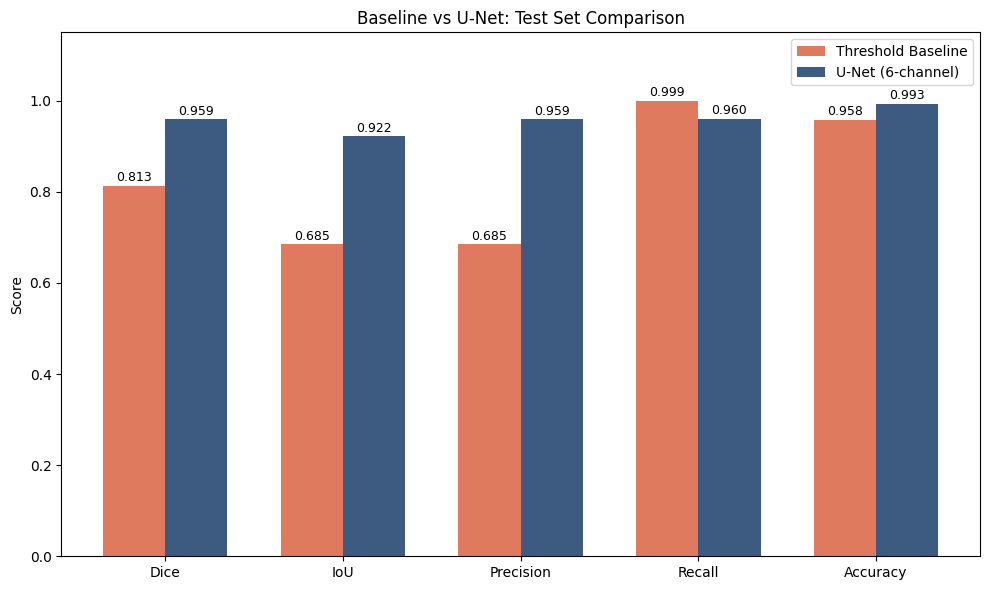

Saved: fig6_baseline_vs_unet_comparison.png


In [42]:
# Aim: plot side-by-side bar chart comparing baseline threshold and U-Net across all key metrics

comparison_metrics = ["Dice", "IoU", "Precision", "Recall", "Accuracy"]
baseline_scores = [baseline_dice_v3, baseline_iou_v3, baseline_precision_v3, baseline_recall_v3, baseline_accuracy_v3]
unet_scores = [test_dice, test_iou, precision, recall, accuracy]

x = np.arange(len(comparison_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_scores, width, label="Threshold Baseline", color="#E07A5F")
bars2 = ax.bar(x + width/2, unet_scores, width, label="U-Net (6-channel)", color="#3D5A80")

ax.set_ylabel("Score")
ax.set_title("Baseline vs U-Net: Test Set Comparison")
ax.set_xticks(x)
ax.set_xticklabels(comparison_metrics)
ax.set_ylim(0, 1.15)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f"{height:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/fig6_baseline_vs_unet_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig6_baseline_vs_unet_comparison.png")

In [47]:
# Aim: convert a sample test patch (SAR stack and label) from npy back to a 6-band GeoTIFF for uploading to the Hugging Face Space

import rasterio
from rasterio.transform import Affine

sample_export_idx = test_df.index[0]
sample_row = test_df.loc[sample_export_idx]

sar_patch = np.load(sample_row["sar_path"]).astype(np.float32)

# using a placeholder identity transform and geographic CRS, since exact
# georeferencing per patch is not tracked in the manifest and is not
# required for testing the model's inference path on the Space
transform = Affine.identity()

export_path = "/kaggle/working/sample_test_patch.tif"

with rasterio.open(
    export_path,
    "w",
    driver="GTiff",
    height=sar_patch.shape[1],
    width=sar_patch.shape[2],
    count=sar_patch.shape[0],
    dtype=sar_patch.dtype,
    crs="EPSG:4326",
    transform=transform,
) as dst:
    dst.write(sar_patch)
    dst.descriptions = ["VV_post", "VH_post", "VV_pre", "VH_pre", "log_ratio", "elevation"]

print(f"Sample patch exported to {export_path}")
print(f"Shape: {sar_patch.shape}, dtype: {sar_patch.dtype}")
print(f"Ground truth flood fraction for this patch: {sample_row['flood_fraction_final']:.4f}")

Sample patch exported to /kaggle/working/sample_test_patch.tif
Shape: (6, 256, 256), dtype: float32
Ground truth flood fraction for this patch: 0.0219


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:377: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
